In [ ]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Diabets](https://www.openml.org/search?type=data&status=active&id=37)

In [2]:
dataset_id = 37
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-10 16:27:51,187] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-10 16:27:51,212] Trial 0 finished with value: 0.8711111111111111 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.8711111111111111.
[I 2025-04-10 16:27:51,220] Trial 1 finished with value: 0.9059259259259258 and parameters: {'penalty': 'l1', 'C': 10}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-10 16:27:51,224] Trial 2 finished with value: 0.9051851851851851 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-10 16:27:51,229] Trial 3 finished with value: 0.9051851851851851 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-10 16:27:51,234] Trial 4 finished with value: 0.9051851851851851 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-10 16:27:51,239] Trial 5 finished with value: 

ROC-AUC = 0.8667
F1 = 0.6531
Accuracy = 0.7792
Precision = 0.7273
Recall = 0.5926


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-10 16:27:51,337] A new study created in memory with name: catboost_optimization
[I 2025-04-10 16:27:54,277] Trial 0 finished with value: 0.8940740740740741 and parameters: {'depth': 10, 'learning_rate': 0.03, 'l2_leaf_reg': 1.0}. Best is trial 0 with value: 0.8940740740740741.
[I 2025-04-10 16:27:54,749] Trial 1 finished with value: 0.9125925925925926 and parameters: {'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 6.0}. Best is trial 1 with value: 0.9125925925925926.
[I 2025-04-10 16:27:57,541] Trial 2 finished with value: 0.9059259259259259 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 3.0}. Best is trial 1 with value: 0.9125925925925926.
[I 2025-04-10 16:28:00,342] Trial 3 finished with value: 0.9059259259259259 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.9125925925925926.
[I 2025-04-10 16:28:00,690] Trial 4 finished with value: 0.9037037037037037 and parameters: {'depth': 2, 'learning_rate'

ROC-AUC = 0.8378
F1 = 0.6939
Accuracy = 0.8052
Precision = 0.7727
Recall = 0.6296


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-10 16:28:18,175] A new study created in memory with name: lgdm_optimization
[I 2025-04-10 16:28:18,856] Trial 0 finished with value: 0.8748148148148148 and parameters: {'num_leaves': 64, 'reg_alpha': 0.1, 'reg_lambda': 1e-05, 'learning_rate': 0.03}. Best is trial 0 with value: 0.8748148148148148.
[I 2025-04-10 16:28:19,570] Trial 1 finished with value: 0.8807407407407407 and parameters: {'num_leaves': 1024, 'reg_alpha': 1e-05, 'reg_lambda': 1e-06, 'learning_rate': 0.1}. Best is trial 1 with value: 0.8807407407407407.
[I 2025-04-10 16:28:19,791] Trial 2 finished with value: 0.874074074074074 and parameters: {'num_leaves': 256, 'reg_alpha': 0.001, 'reg_lambda': 1e-07, 'learning_rate': 0.3}. Best is trial 1 with value: 0.8807407407407407.
[I 2025-04-10 16:28:19,936] Trial 3 finished with value: 0.8918518518518519 and parameters: {'num_leaves': 4, 'reg_alpha': 0.01, 'reg_lambda': 0.1, 'learning_rate': 0.03}. Best is trial 3 with value: 0.8918518518518519.
[I 2025-04-10 16:28:20,

ROC-AUC = 0.8107
F1 = 0.5957
Accuracy = 0.7532
Precision = 0.7000
Recall = 0.5185


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


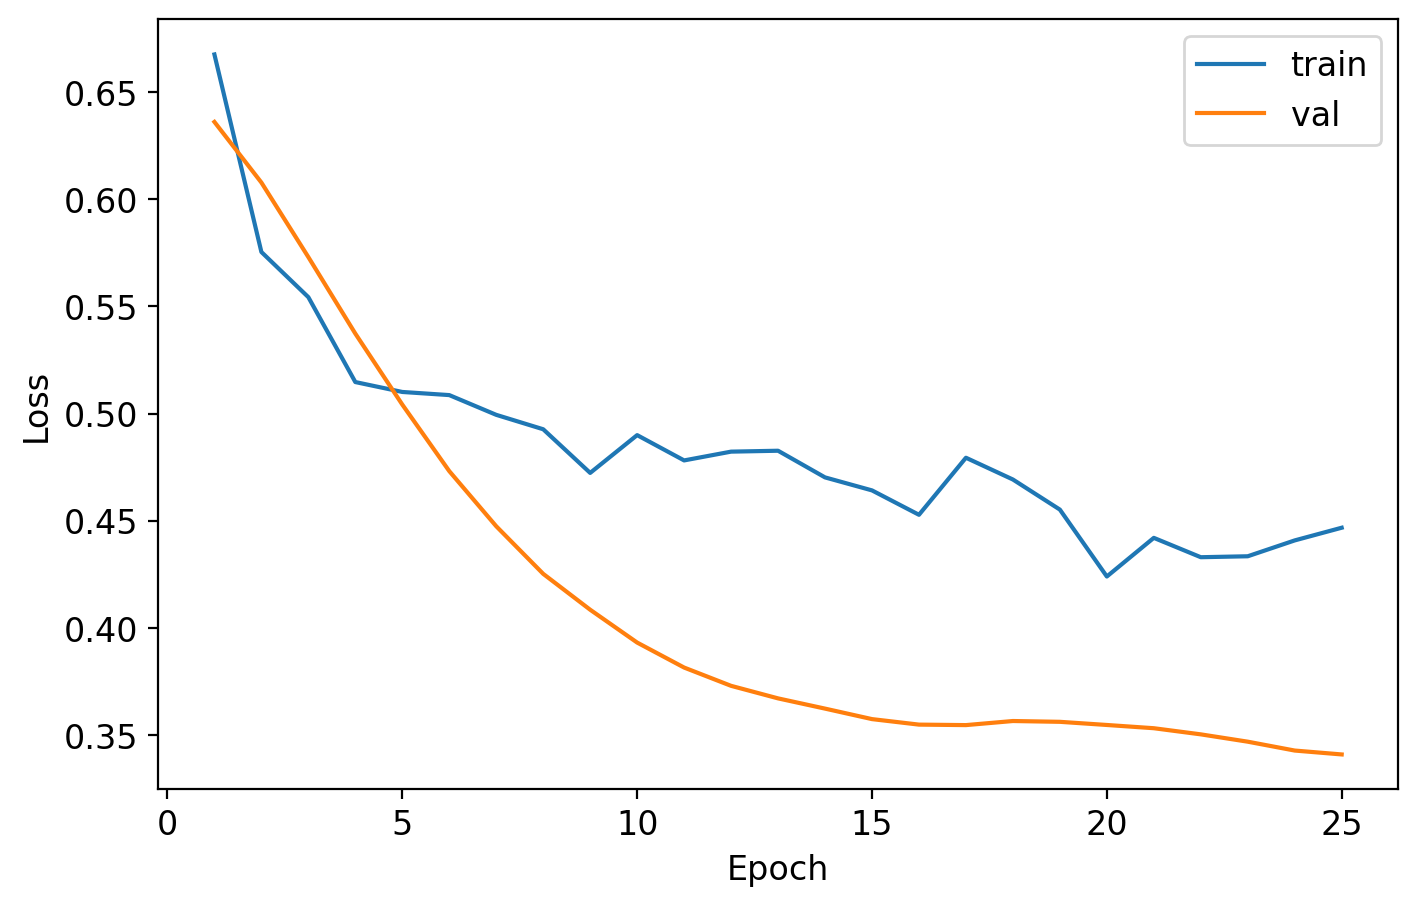

Epoch 25: train loss = 0.4468; valid loss = 0.3410


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.8689
F1 = 0.7200
Accuracy = 0.8182
Precision = 0.7826
Recall = 0.6667
